# Two-Level System

I am considering interaction between an atom and 1D light field as outlined in RbQ Method Overleaf (freespace2level pdf). A single coherent beam interacting with a single atom has the Hamiltonian ($\sqrt{2g}$?? anyways just call it $g$ for now): 


The Hamiltonian is:

$$\hat{H} = g \hat{\textbf{a}}(t)\hat{\sigma}_+ + g^* \hat{\textbf{a}}^\dagger(t)\hat{\sigma}_-$$

- $g$ is the coupling betwen the light and atom.
- $\hat{\textbf{a}}(t)$ is a bath operator which is different at each point in time (?). This is defined as $\hat{\textbf{a}}(t)= \hat{a}_0(t) + \alpha(t) $, where $\hat{a}_0(t)$ is the vacuum annihilation operator. 

For simplicity, I am considering the case where the driving field (photon) is coherent ($\alpha$ and $g$ are both real) interacts with a two-level system (TLS). We also ignore the vacuum field, which is under the assumption that the $\alpha$ is much larger than vacuum. Eventually, we will have to account for vacuum since our $\alpha$ is small. This leads to:

$$\hat{H} = -g(t)\alpha(t) \hat{\sigma}_x$$

We will solve this time-dependent Hamiltonian and determine the expectation value of the atom's state (not photon?), to see if the atom has "spun up" as expected. I am currently assuming that the coupling strength $g$ is constant. 

In Qutip, ways to solve the time-dependent Hamiltonian are found in https://qutip.org/docs/4.7/guide/dynamics/dynamics-time.html. 

------------------------------------------------
Determine the expectation value of the photon state, not quantum state of light being used.

We will observe in the three-level system that efficiencies don't work well because of the AC stark shift - to correct this, detune frequencies of input light which corrects stark shift during the simulation (phase factor from h). We will pick up phase in the template if we don't account for stark shift (diff dressed state energy shift between the 2 ground states).

In [310]:
import matplotlib.pyplot as plt
import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

First, we will assume the incoming wavepacket has a Gaussian profile (normalized):

$$\alpha(t) = \frac{1}{\sigma\sqrt{2\pi}} e^{-(x-\mu)^2/2\sigma^2}$$

where $\mu$, $\sigma$ are the mean and standard deviation of the Gaussian, respectively. 



In [311]:
### INPUT PARAMETERS
T = 5.0 # total time (input pulse "duration")
N = 1000 # number of time steps
time = np.linspace(0, T, N)

mu, sigma = T/2, T/10
a = 0.1 #1/(sigma*np.sqrt(2*np.pi)) # (if want normalized area)

def alpha_in(t):
    return a * np.exp(-((t - mu)**2) / (2 * sigma**2)) # Gaussian input
alpha = alpha_in(time)
print("Area of alpha:", integrate.simps(alpha, time))
g = 1 # coupling strength between atom and light

Area of alpha: 0.1253313418790367


In [312]:
H1 = Qobj([[0, 1], [1, 0]])  
def H1_coeff(t, args): 
    return g * alpha_in(t) 

H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H = [H0,[H1, H1_coeff]] # Hamiltonian

Here, we can see the coupling shape needed to maximally spin up kind of matches the math in the Gorshkov paper. This shape intuitively makes sense because you have a large increase in the coupling at the beginning to "get" as much of the incoming pulse as possible. 

(0.0, 10.0)

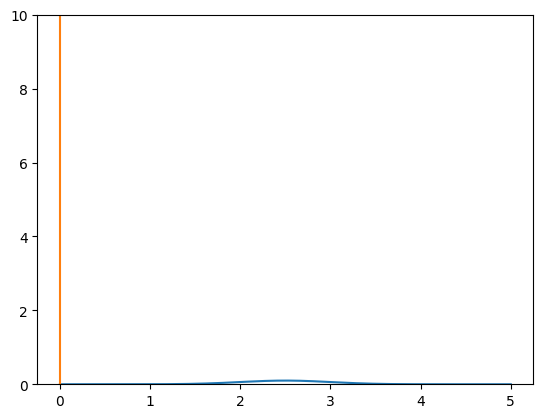

In [313]:
test = []
for i in range(0, len(time)):
    if i == 0: g_test = 0
    else: g_test = (np.pi/2)/integrate.simps(alpha[0:i+1], time[0:i+1]) # coupling that "maximizes" overlap integral
    test.append(g_test)
plt.plot(time, alpha)
plt.plot(time, test)
plt.ylim([0, 10])

The spin value is defined as: $ S(t) = \langle \hat{\sigma}_- \rangle $ where $ \hat{\sigma}_- = | g \rangle \langle e |$. If $S=0$ (see picture), that doesn't mean your atom didn't get spun up since $S=c_gc_e^*$: even if the atom is excited ($c_e=1$), $c_g = 0$ so $S=0$. So what is this actually showing?? This metric doesn't refer to amount of spin stored it seems. Should we be trying to maximize S or excited state probability?

In [317]:
# DISSIPATION OPERATORES (collapse operators)
c_op_list = []

### SIMULATE: starting from the ground state, solve Schrodinger equation (no dissipation) 
psi0 = basis(2, 0) # |g> in the sigma z basis = [1, 0]'
result = mesolve(H, psi0, time, c_op_list) 

prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator

for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][0][0], result.states[i][1][0]
    S = expect(sigmam(), result.states[i])
    if S != -p_e*p_g.conjugate():
        print("Mismatch: ", S, p_e*p_g.conjugate())
    S_expect = np.append(S_expect, S)
    
    prob_ground = np.append(prob_ground, p_g**2)
    prob_excited = np.append(prob_excited, p_e**2)

Max excited state population: 0j


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 0.1)

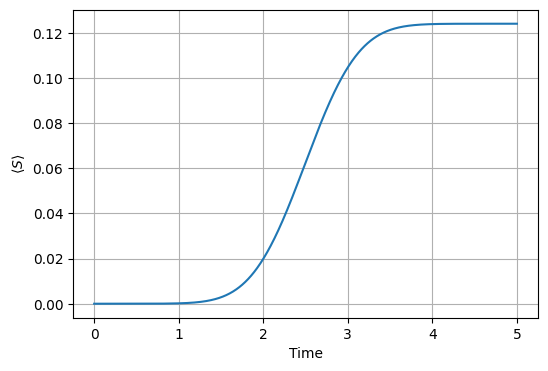

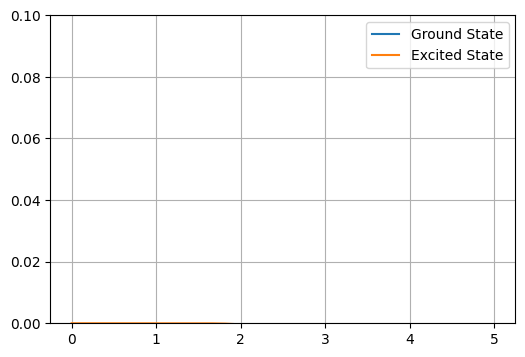

In [318]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect))
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State')
plt.legend(); plt.grid()
print("Max excited state population:", max(prob_excited))
plt.ylim([0, 0.1])

### Checking simulation analytically
We can check the results of this mesolve by calculating the time-evolution operator ourselves. From the pdf: $\hat{H}$ commutes with itself at different times so the expansion for the time evolution operator becomes (taking $\hbar$ to be $1$):

$$
U(t) = e^{-i\hat{H}t} = e^{i\hat{\sigma}_x \int_0^t g(\tau)\alpha(\tau)d\tau}
$$

From Wikipedia on Pauli matrix exponentials, we define and have:

$$
\Theta(t) = \int_0^t g(\tau) \alpha(\tau) d\tau
$$
which is the overlap integral, and

$$
U(t) = \cos(\Theta(t)) \hat{I} + i \sin(\Theta(t)) \hat{\sigma}_x
$$

We can then write $\ket{\psi(t)} = U(t) \ket{\psi_0}$.

We have two cases that we should check:

- Case 1: If the template is orthogonal to the incoming wavepacket, aka $g(t)$ orthogonal to $\alpha(t)$, the atom's state should not change.

$$ \int_0^t g(\tau)\alpha(\tau) d \tau=0 \rightarrow U(t)=\hat{I} $$

- Case 2: If the template perfectly matches the incoming wavepacket, aka $g(t) = \alpha(t)$ (?), the atom's state should become excited. 

$$ \int_0^t g(\tau)\alpha(\tau) d \tau=1 \rightarrow U(t)=i\hat{\sigma}_x $$

(does the above integral have to be pi/2? to make it 0/1)


In [ ]:
Theta = np.array([])
prob_ground = []
prob_excited = []
psi_current = np.array([1, 0])  # initial state |g>
S = []

for i in range(0, len(time)):
    # Case 2: Let g be some constant that magically cancels out the integral of alpha. 
    #if i == 0: g = 0
    #else: g = (np.pi/2) / integrate.simps(alpha[0:i+1], time[0:i+1]) 

    integral_value, _ = integrate.quad(lambda x: g * alpha_in(x), 0, time[i])
    Theta = np.append(Theta, integral_value)

    U_matrix = np.cos(integral_value)*np.eye(2) + 1j*np.sin(integral_value) * np.array([[0, 1], [1, 0]])
    #U_matrix = np.eye(2) # Expected result of Case 1
    #U_matrix = 1j*np.array([[0, 1], [1, 0]]) # Expected result of Case 2

    p_e, p_g = (U_matrix @ psi_current)[1], (U_matrix @ psi_current)[0]
    S = np.append(S, p_e*p_g.conjugate())

    prob_ground = np.append(prob_ground, (np.linalg.norm((U_matrix @ psi_current)[0]))**2)
    prob_excited = np.append(prob_excited, (np.linalg.norm((U_matrix @ psi_current)[1]))**2)

Max excited state population: 0.015625870805735173


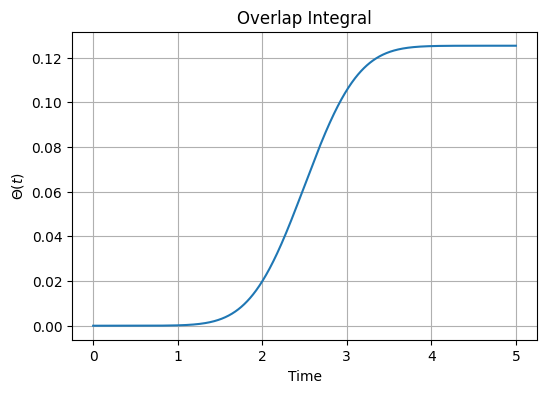

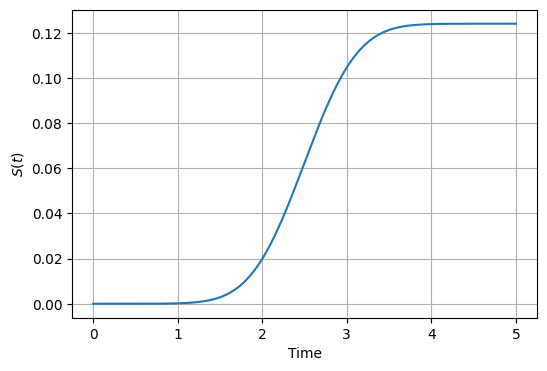

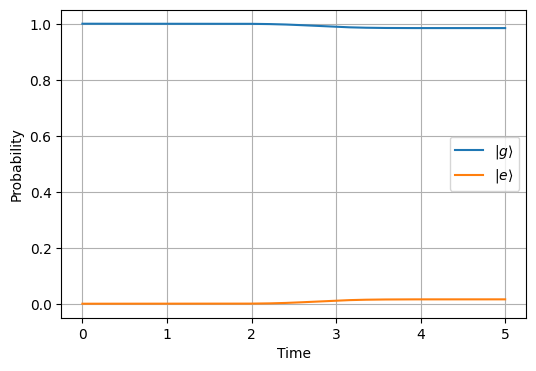

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(time, (Theta), label=r'$\Theta(t)$'); plt.grid()
plt.xlabel('Time'); plt.ylabel(r'$\Theta(t)$'); plt.title('Overlap Integral')

plt.figure(figsize=(6,4))
plt.plot(time, abs(S), label=r'$S(t)$')
plt.xlabel('Time'); plt.ylabel(r'$S(t)$'); plt.grid()

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label=r'$|g\rangle$')
plt.plot(time, prob_excited, label=r'$|e\rangle$')
plt.xlabel('Time'); plt.ylabel('Probability'); plt.grid()

plt.legend()
print("Max excited state population:", max(prob_excited))

## Adding in decay terms

Currently, we do not account for the atom spontaneously decaying (e to g). For a given bath mode, the Lindblad collapse operators are given by $$L= -g^*\hat{\sigma}_- $$ where $g$ is a function of time and $\hat{\sigma}_-$ is the lowering operator on the TLS ($\ket{g}\bra{e}$).

In [388]:
### INPUT PARAMETERS (same as above)
T = 5.0 # total time (input pulse "duration")
N = 1000 # number of time steps
time = np.linspace(0, T, N)

mu, sigma = T/2, T/10
a = 0.1 * np.sqrt(1/(sigma*np.sqrt(np.pi))) # (if want normalized area)

# Temporal mode = basis --> energy = 1, 
# average energy of 1 single photon (approximate this with alpha^2 integral = 1)
def alpha_in(t):
    return a * np.exp(-((t - mu)**2) / (2 * sigma**2)) # Gaussian input
alpha = alpha_in(time)
print("Area of alpha:", integrate.simps(alpha**2, time)) # probability of single photon 

g = 1 # coupling strength between atom and light

#H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H1 = Qobj([[0, 1], [1, 0]])  
def H1_coeff(t, args): 
    return g * alpha_in(t) 
H = [[H1, H1_coeff]] # Hamiltonian

Area of alpha: 0.009999999999984625


In [389]:
# DISSIPATION OPERATORES (collapse operators)
c_op_list = [-np.conjugate(g)*sigmam()] # Lindblad dissipation (collapse) operators

### SIMULATE: starting from the ground state, solve Schrodinger equation (with dissipation) 
psi0 = basis(2, 1) # |g> in the sigma z basis = [1, 0]'
result = mesolve(H, psi0, time, c_op_list) 

prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator


for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][0][0], result.states[i][1][1]
    if np.imag(p_g) != 0 or np.imag(p_e) != 0:
        print("Imaginary part detected: ", p_g, p_e)
    S = expect(sigmam(), result.states[i])
    S_expect = np.append(S_expect, S)
    
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)

Max excited state population: (1+0j)


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 0.1)

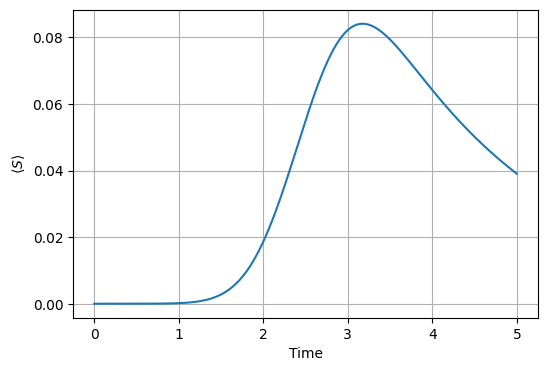

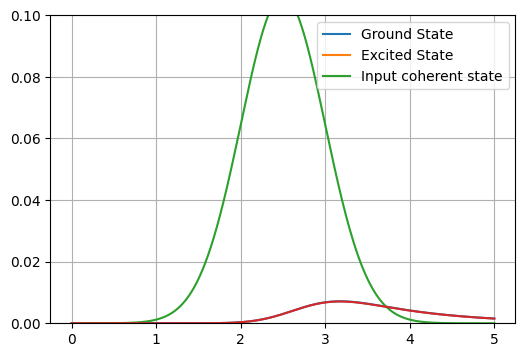

In [390]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect))
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State')
plt.plot(time, alpha, label='Input coherent state')
plt.plot(time, abs(S_expect)**2)
plt.legend(); plt.grid()
print("Max excited state population:", max(prob_excited))
plt.ylim([0, 0.1])

### Include optimal g 

We want to find the optimal shaped write pulse $g(t)$ (aka the ideal coupling) that maximizes excited state probability (the amount of excited state absorbed from the coherent state) with decay. We don't want to change $\alpha(t)$ since we want to accommodate an arbitrary temporal mode. From Eq. 56 in the freespace2level pdf, we have 

$$
g^*(t) = \frac{k_{||}(t)}{\sqrt{\int_{-\infty}^t |k_{||}(t)|^2dt}}
$$

where $k_{||}(t)$ is the normalized template that overlaps with the incoming signal. This is similar to Gorshkov but without the phase term. We will set this to be equal to $\alpha_{in}$ since that would be a perfect overlap. 

What does normalized mean? I interpret this as $ \int_{-\infty}^\infty{k(t)dt} = 1$, should it be $ \int_{-\infty}^\infty{k(t)^2dt} = 1$?

In [386]:
print(sigmam())
print(basis(2, 0))
print(sigmap())

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 0.]
 [1. 0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0. 1.]
 [0. 0.]]


Area of alpha: 0.009999999999984625
Area of template k(t): 0.9999994266998895


(0.0, 14.5)

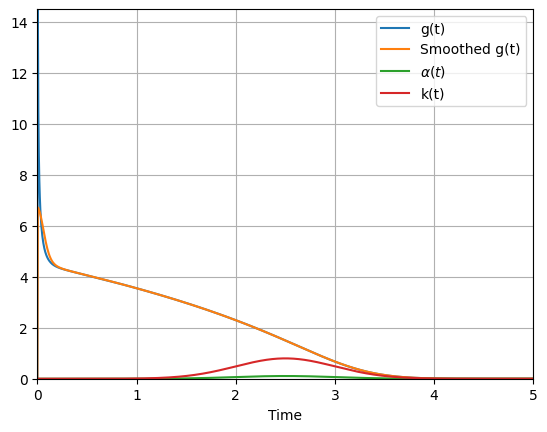

In [393]:
### INPUT PARAMETERS
T = 5 # total time (input pulse "duration")
N = 1000 # number of time steps
time = np.linspace(0, T, N)

mu, sigma = T/2, T/10
a = 0.1 * np.sqrt(1/(sigma*np.sqrt(np.pi))) # (if want normalized area)

### GAUSSIAN INPUT (at time t)
def alpha_in(t):
    return a * np.exp(-((t-mu)**2) / (2*sigma**2)) 
alpha = alpha_in(time)
print("Area of alpha:", integrate.simps(alpha**2, time))

### TEMPLATE FUNCTION (at time t)
def k(t):
    a = 1/(sigma*np.sqrt(2*np.pi)) # for normalized area
    return a * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # -inf to t
    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0

g_vals, k_vals = [], []
for t in time: 
    g_vals.append(g(t)) 
    k_vals.append(k(t))

print("Area of template k(t):", integrate.simps(np.array(k_vals), time))

g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
def g_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

plt.plot(time, g_vals, label='g(t)')
plt.plot(time, [g_smoothed(t) for t in time], label='Smoothed g(t)')  # Plot smoothed g(t)
plt.plot(time, alpha_in(time), label=r'$\alpha(t)$')
plt.plot(time, k_vals, label='k(t)')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.xlim([0, 5]); plt.ylim([0, 14.5])

In [398]:
### HAMILTONIAN
H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H1 = Qobj([[0, 1], [1, 0]])  
def H1_coeff(t, args): 
    return g_smoothed(t) * alpha_in(t) 
H = [H0,[H1, H1_coeff]] # Final Hamiltonian

# DISSIPATION OPERATORES (collapse operators)
def col_coeff(t, args):  # coefficient function
    return -np.conjugate(g_smoothed(t))
c_op_list = [[sigmap(), col_coeff]]  # time-dependent collapse term

'''plt.figure()
H1_coeff_vals = []
for t in time:  # Check every 100th time step
    H1_coeff_vals.append(H[1][1](t, None)) # H1_coeff at time t
plt.plot(time, H1_coeff_vals)'''

'plt.figure()\nH1_coeff_vals = []\nfor t in time:  # Check every 100th time step\n    H1_coeff_vals.append(H[1][1](t, None)) # H1_coeff at time t\nplt.plot(time, H1_coeff_vals)'

$$S^2 = \int \alpha^2 dt$$

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
0.09900358912618114
Max excited state population: (0.00993349004996998+0j)
(0.00993349004996998+0j)


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


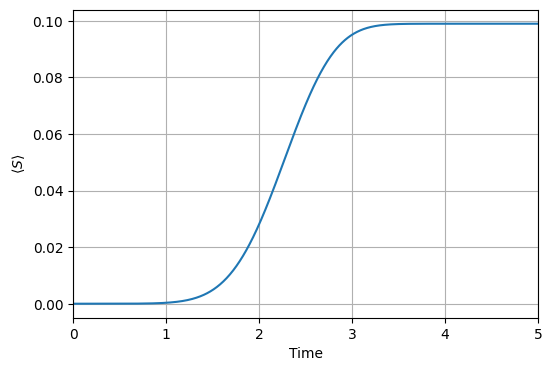

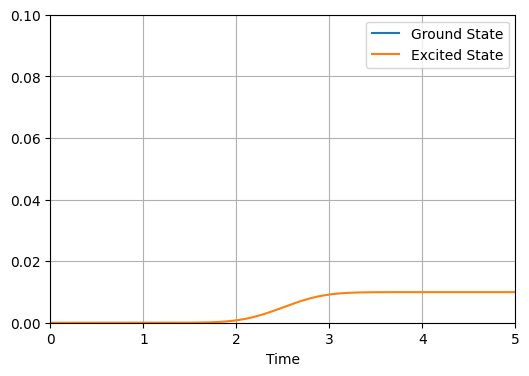

In [399]:
### SIMULATE: starting from the ground state, solve Schrodinger equation (no dissipation) 
psi0 = basis(2, 0) # |g> in the sigma z basis = [1, 0]'
print(psi0)
result = mesolve(H, psi0, time, c_op_list) 

prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator

for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][0][0], result.states[i][1][1]
    S = expect(sigmam(), result.states[i])
    S_expect = np.append(S_expect, S)
    
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)

plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect))
print(abs(S_expect[-1]))
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid()
plt.xlim([0, 5])

plt.figure(figsize=(6,4))
plt.plot(time, prob_ground, label='Ground State')
plt.plot(time, prob_excited, label='Excited State')
#plt.plot(time, alpha, label='Input coherent state')
plt.legend(); plt.grid(); plt.xlabel('Time')
print("Max excited state population:", max(prob_excited))
plt.xlim([0, 5])
plt.ylim([0, 0.1])
print(prob_excited[-1])

$$S^2 = \int_0^t {\alpha^2_{in}(t)dt}$$

0.099999999999919


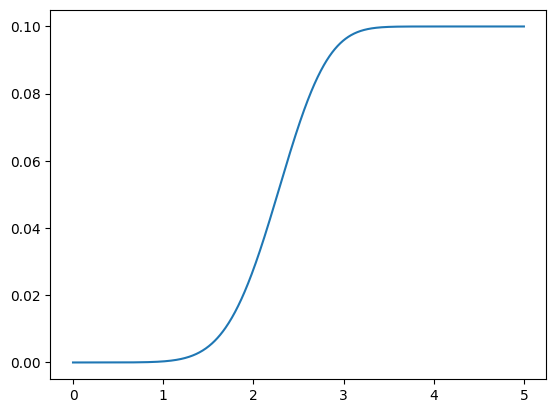

In [379]:
S_squared = []
for i in range(0, len(time)):
    if i == 0: S_squared.append(0)
    else:
        S_squared.append(integrate.simps(abs(alpha[0:i])**2, time[0:i]))
plt.plot(time, np.sqrt(S_squared))
print(np.sqrt(S_squared[-1]))

Questions:
- What is $\alpha(t)$? (how does the $\alpha$ look as a matrix ?? to sum with the vacuum annihilation operator)
- The incoming state is coherent so this simulation is not entirely accurate - but single photons can't be coherent states but isn't that what we're trying to detect using RbQ? I'm confused now lol, the template is not coherent?
- When we tensor these two, it seems like you're treating the two Hilbert spaces as independent. Is this the case?
- We are assuming this $\alpha(t)$ is coherent, but this is not accurate for a single photon because a coherent state is a sum of Fock states (so need more than 1 photon physically?)
- Can there be decay arising from the bath terms, not just spontaneous decay? like the photon may be deformed as it's travelling or something?
- incoming pulse is always gaussian? what is gaussian here
- What is the metric for how "good" our system is behaving?


## (ignore) Testing with actual operators instead of $\alpha$

In [ ]:
# OPERATORS
N = 2  # dimension of Hilbert space
a = qutip.tensor(qutip.destroy(N), qutip.qeye(2)) # Annihilation operator for field (acts trivally on the atom) 
sm = qutip.tensor(qutip.qeye(N), qutip.sigmam()) # Lowering operator for the atom
sp = qutip.tensor(qutip.qeye(N), qutip.sigmap()) # Raising operator for the atom

In [ ]:
g = 1 # coupling strength between atom and light

H1 = Qobj([[0, 1], [1, 0]])  
def H1_coeff(t, args): 
    return g * alpha_in(t) 

H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H = [H0,[H1, H1_coeff]] # Hamiltonian

In [ ]:
c_op_list = [-np.conjugate(g)*sm] # Lindblad dissipation (collapse) operators
e_ee = qutip.sigmap()*qutip.sigmam()
e_ops=[a, e_ee] # expectation values we want (of the bath operator to get alpha)

### SIMULATE: starting from the ground state, solve master equation 
psi0 = basis(2, 0) # For Qutip, |g> in the sigma z basis = [1, 0]'
result = mesolve(H, psi0, time, c_op_list, e_ops=e_ops) 

TypeError: The coefficient function must return a number